DAY------------------------------------------------------. 4

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [2]:
!pip install statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv("../Data/online_retail_feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [7]:
df["TotalSales"] = df["Quantity"] * df["Price"]

df = df.sort_values("InvoiceDate")

df.set_index("InvoiceDate", inplace=True)

In [9]:
daily_sales = df["TotalSales"].resample("D").sum()

daily_sales = daily_sales.asfreq("D")

daily_sales.fillna(0, inplace=True)

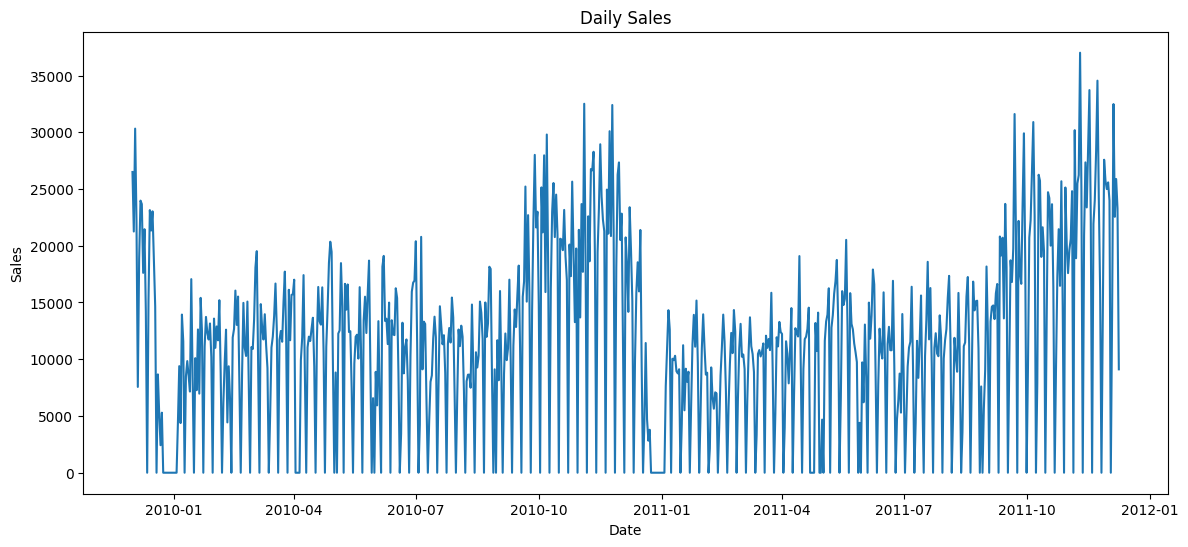

In [10]:
plt.figure(figsize=(14,6))

plt.plot(daily_sales)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [11]:
weekly_sales = daily_sales.resample("W").sum()

monthly_sales = daily_sales.resample("M").sum()

C:\Users\devar\AppData\Local\Temp\ipykernel_6816\2119650300.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample("M").sum()


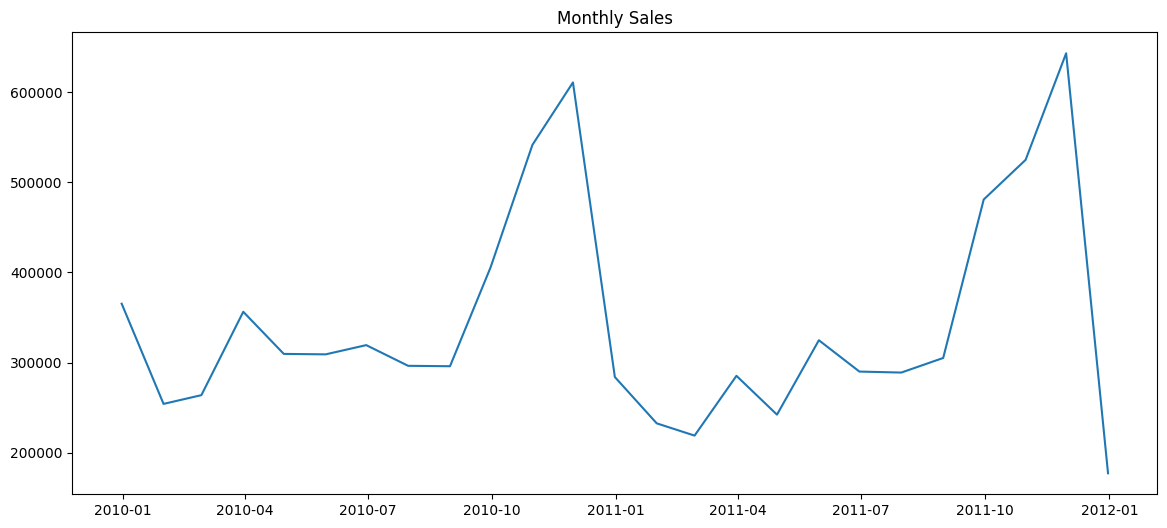

In [12]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales)

plt.title("Monthly Sales")

plt.show()

In [15]:
rolling_mean = daily_sales.rolling(window=7).mean()

rolling_std = daily_sales.rolling(window=7).std()

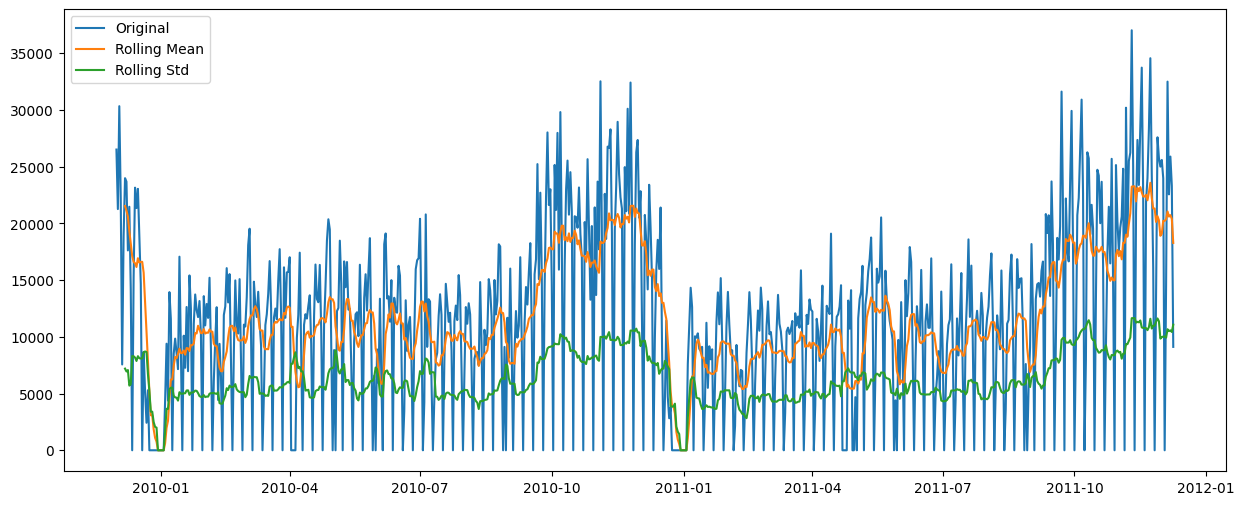

In [16]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales,label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.show()

In [19]:
result = adfuller(daily_sales)

In [20]:
print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Lags Used :", result[2])

print("Number of Observations :", result[3])

print("\nCritical Values")

for key,value in result[4].items():

    print(key,":",value)

ADF Statistic : -2.4674461963766374
p-value : 0.12359723638027942
Lags Used : 20
Number of Observations : 718

Critical Values
1% : -3.439490435810785
5% : -2.8655738086413374
10% : -2.568918067209286


In [21]:
if result[1] < 0.05:

    print("The series is Stationary")

else:

    print("The series is NOT Stationary")

The series is NOT Stationary


In [24]:
daily_sales_diff = daily_sales.diff()

daily_sales_diff = daily_sales_diff.dropna()

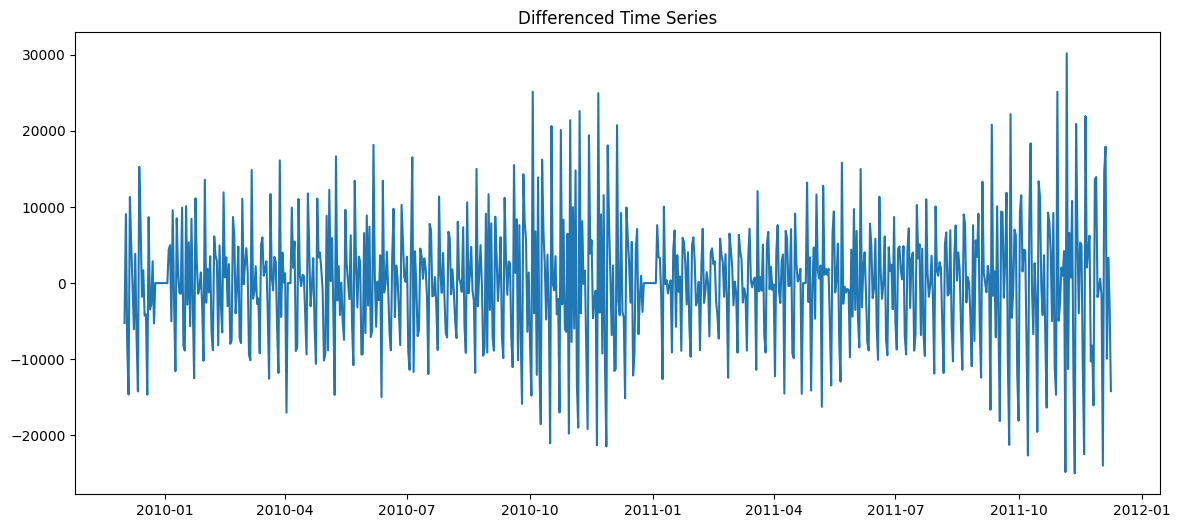

In [25]:
plt.figure(figsize=(14,6))

plt.plot(daily_sales_diff)

plt.title("Differenced Time Series")

plt.show()

In [26]:
result = adfuller(daily_sales_diff)

print("p-value :", result[1])

p-value : 4.303270483773665e-13


In [27]:
df = df.dropna()

In [28]:
df.to_csv(

    "time_series_ready.csv",

    index=True

)

print("Time-Series Dataset Saved Successfully!")

Time-Series Dataset Saved Successfully!
